In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import json

df = pd.read_csv('../data/processed/dengue_features_final.csv')
df['month'] = pd.to_datetime(df['month'])

print(f"Data loaded: {df.shape}")
df.head()

Data loaded: (129, 14)


,month,cases,rainfall,temperature,year,month_num,quarter,cases_lag_1,cases_lag_2,cases_lag_3,cases_rolling_3,rainfall_lag_1,temp_lag_1,temp_rain_product
0,2012-04-01,363,260.6,24.8,2012,4,2,231.0,258.0,338.0,275.666667,313.4,24.4,7646.96
1,2012-05-01,338,292.0,24.8,2012,5,2,363.0,231.0,258.0,284.000000,260.6,24.8,6462.88
2,2012-06-01,468,53.0,26.3,2012,6,2,338.0,363.0,231.0,310.666667,292.0,24.8,7241.60
3,2012-07-01,601,130.8,25.3,2012,7,3,468.0,338.0,363.0,389.666667,53.0,26.3,1393.90
4,2012-08-01,436,119.0,25.4,2012,8,3,601.0,468.0,338.0,469.000000,130.8,25.3,3309.24


In [56]:
feature_cols = ['cases_lag_1', 'cases_lag_2', 'cases_lag_3', 'cases_rolling_3',
                'rainfall', 'rainfall_lag_1', 'temperature', 'temp_lag_1',
                'temp_rain_product', 'month_num', 'quarter']

X = df[feature_cols]
y = df['cases']

print(f"Total samples: {len(df)}")
print(f"Features: {len(feature_cols)}")

Total samples: 129
Features: 11


In [57]:
# CELL 3
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(f"Training: {len(X_train)} samples")
print(f"Testing: {len(X_test)} samples")

Training: 103 samples
Testing: 26 samples


In [58]:
# CELL 4
model = xgb.XGBRegressor(
    n_estimators=50,
    learning_rate=0.05,
    max_depth=3,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    objective='reg:squarederror'
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=50,
             n_jobs=None, num_parallel_tree=None, ...)

In [59]:
# Make predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [60]:
# Calculate metrics
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)


test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

print("\nTraining Set:")
print(f"MAE:  {train_mae:.2f}")
print(f"RMSE: {train_rmse:.2f}")
print(f"R²:   {train_r2:.3f}")

print("\nTest Set:")
print(f"MAE:  {test_mae:.2f}")
print(f"RMSE: {test_rmse:.2f}")
print(f"R²:   {test_r2:.3f}")


Training Set:
MAE:  265.94
RMSE: 457.25
R²:   0.851

Test Set:
MAE:  521.10
RMSE: 851.81
R²:   0.725


In [61]:
# Load baseline for comparison
with open('../data/processed/baseline_results.json', 'r') as f:
    baseline = json.load(f)

improvement = ((baseline['mae'] - test_mae) / baseline['mae']) * 100
print(f"\n🎯 Improvement over baseline: {improvement:.1f}%")
print(f"   Baseline MAE: {baseline['mae']:.2f}")
print(f"   XGBoost MAE: {test_mae:.2f}")


🎯 Improvement over baseline: 2.6%
   Baseline MAE: 534.88
   XGBoost MAE: 521.10


C:\Users\buoxu\AppData\Local\Temp\ipykernel_8528\546788610.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis')


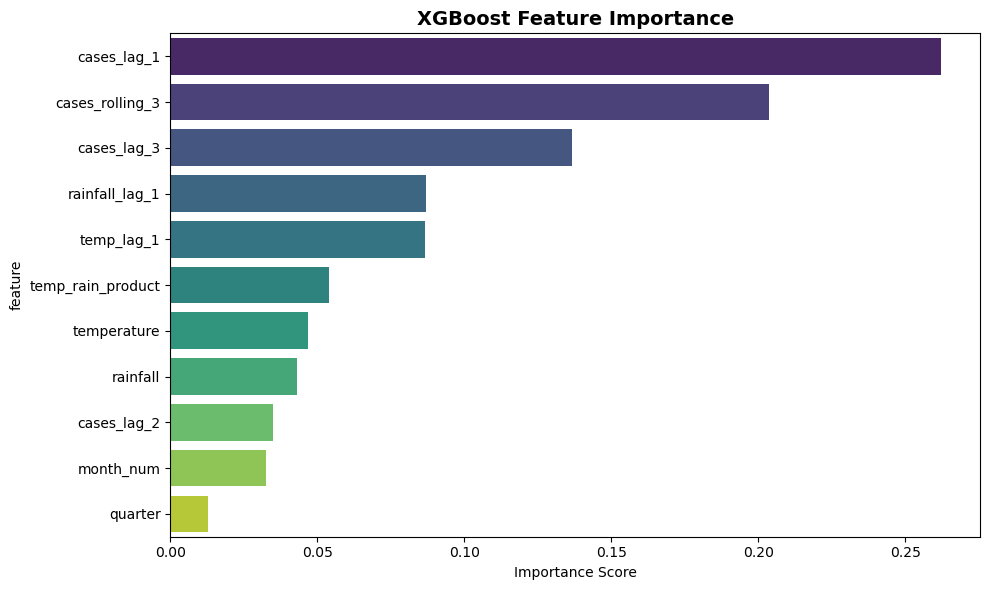


Top 5 Most Important Features:
           feature  importance
0      cases_lag_1    0.262255
3  cases_rolling_3    0.203706
2      cases_lag_3    0.136533
5   rainfall_lag_1    0.087003
7       temp_lag_1    0.086633


In [62]:
# Feature importance
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis')
plt.title('XGBoost Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../images/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTop 5 Most Important Features:")
print(importance_df.head())

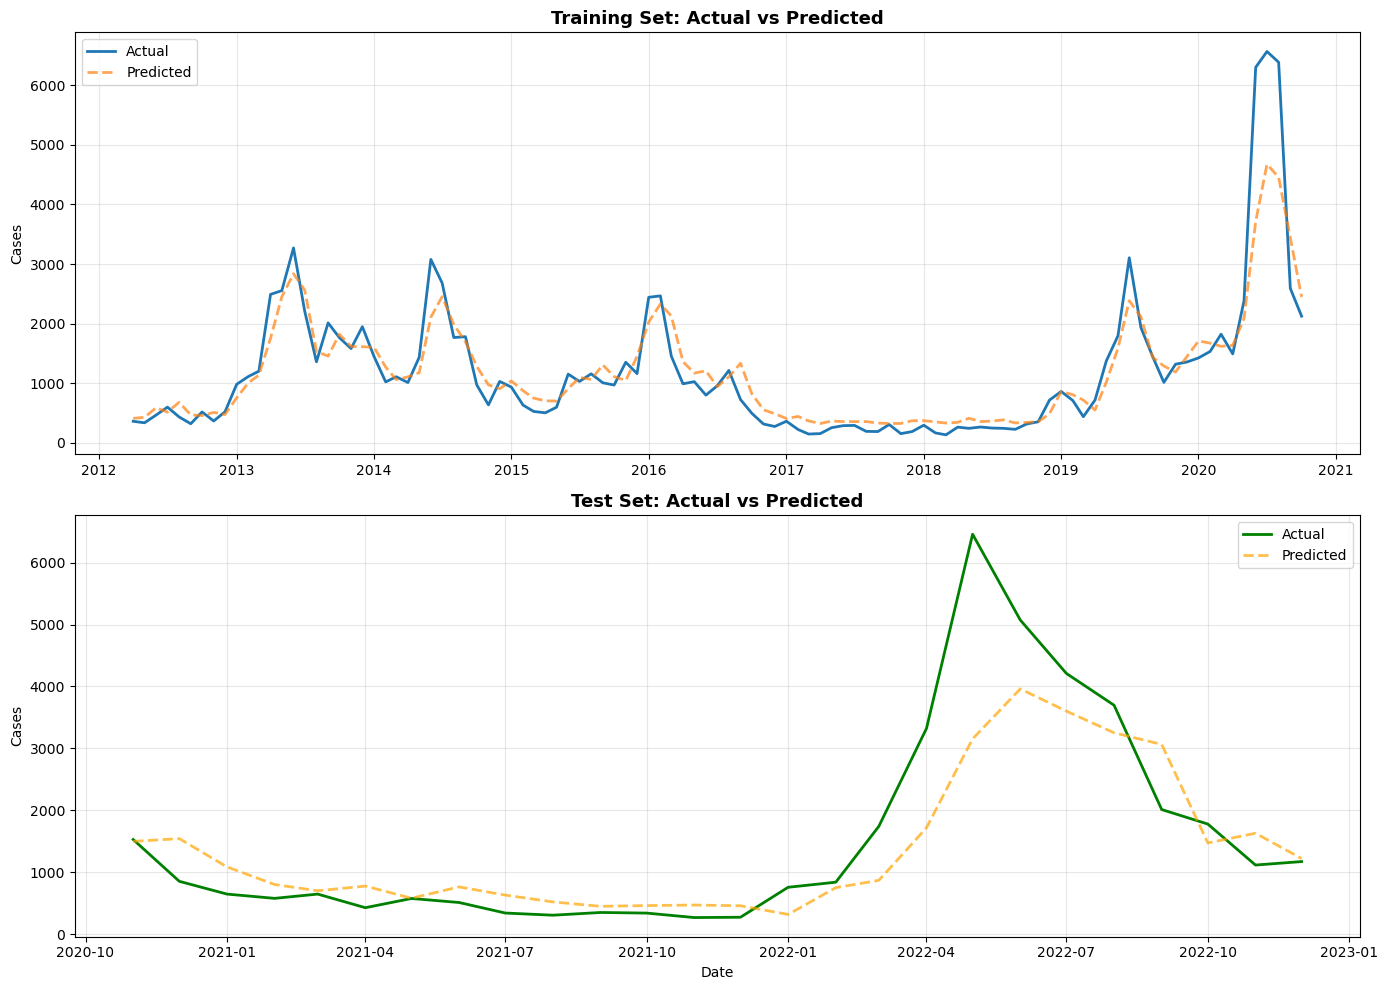

In [63]:
# Visualize predictions vs actual
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Training set
axes[0].plot(df.iloc[:split_index]['month'], y_train, label='Actual', linewidth=2)
axes[0].plot(df.iloc[:split_index]['month'], y_train_pred, 
             label='Predicted', linewidth=2, alpha=0.7, linestyle='--')
axes[0].set_title('Training Set: Actual vs Predicted', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Cases')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Test set
axes[1].plot(df.iloc[split_index:]['month'], y_test, label='Actual', 
             linewidth=2, color='green')
axes[1].plot(df.iloc[split_index:]['month'], y_test_pred, 
             label='Predicted', linewidth=2, alpha=0.7, linestyle='--', color='orange')
axes[1].set_title('Test Set: Actual vs Predicted', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Cases')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../images/xgboost_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

In [64]:
# Save model and results
import joblib
joblib.dump(model, '../models/xgboost_model.pkl')

xgb_results = {
    'model': 'XGBoost',
    'train_mae': train_mae,
    'train_rmse': train_rmse,
    'train_r2': train_r2,
    'test_mae': test_mae,
    'test_rmse': test_rmse,
    'test_r2': test_r2,
    'improvement_over_baseline': improvement
}

with open('../data/processed/xgboost_results.json', 'w') as f:
    json.dump(xgb_results, f, indent=2)

print("Model saved: models/xgboost_model.pkl")
print("Results saved: data/processed/xgboost_results.json")

Model saved: models/xgboost_model.pkl
Results saved: data/processed/xgboost_results.json


# XGBoost Model  

## Performance:
**Test Set:**
- Improvement over baseline: 2.6%
- Baseline MAE: 534.88
- XGBoost MAE: 521.10

## Top Features:
1. cases_lag_1
2. cases_rolling_3
3. cases_lag_3   